# MNIST Multiclass Predictive Pipeline

## End-to-End Classification, Benchmarking, and Robustness Analysis

This project develops an end-to-end multiclass machine learning pipeline for handwritten digit classification using the MNIST (`mnist_784`) dataset.

The project covers:

1. Dataset loading and exploratory data analysis (EDA)
2. Stratified train, validation, and test splitting
3. Pixel normalization and preprocessing
4. Training and hyperparameter comparison of three different classifiers
5. Independent test-set evaluation
6. Comparative performance analysis
7. Class masking and out-of-distribution (OOD) evaluation
8. Inference on personally handwritten digits
9. Analysis of model limitations, robustness, and computational cost

The objective is not only to obtain high classification accuracy, but also to understand how different machine learning approaches behave under standard and challenging conditions.

In [102]:
import sys
import platform
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns
from PIL import Image
import tensorflow as tf

print("===== SYSTEM =====")
print("Architecture:", platform.machine())

print("\n===== PYTHON =====")
print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\n===== CORE LIBRARIES =====")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("Pillow:", Image.__version__)

print("\n===== TENSORFLOW =====")
print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__)

print("\nAvailable devices:")
for device in tf.config.list_physical_devices():
    print(device)

===== SYSTEM =====
Architecture: arm64

===== PYTHON =====
Python executable:
/opt/miniconda3/envs/mnist-pipeline/bin/python

Python version:
3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:38:15) [Clang 20.1.8 ]

===== CORE LIBRARIES =====
NumPy: 2.0.2
Pandas: 3.0.5
Scikit-learn: 1.9.0
Matplotlib: 3.11.1
Seaborn: 0.13.2
Pillow: 12.3.0

===== TENSORFLOW =====
TensorFlow: 2.18.1
Keras: 3.15.1

Available devices:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


# Phase 1 — Dataset and Exploratory Analysis

The MNIST dataset contains grayscale images of handwritten digits from 0 to 9.

Each image has a resolution of 28 × 28 pixels. For the machine learning models, each image is represented as a flattened vector containing 784 features (28 × 28).

Pixel intensities range from 0 to 255, where 0 represents black and 255 represents white.

In [103]:
# Import the libraries required for dataset loading and basic analysis.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml


# Load the MNIST dataset from OpenML.
# as_frame=False keeps the data in NumPy array format.
mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
    parser="auto"
)

# Store the image data and convert the target labels to integers.
X = mnist.data
y = mnist.target.astype(np.uint8)

In [104]:
# Inspect the dimensions and basic data types.
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Number of classes:", len(np.unique(y)))
print("Feature data type:", X.dtype)
print("Target data type:", y.dtype)

Feature matrix shape: (70000, 784)
Target vector shape: (70000,)
Number of classes: 10
Feature data type: int64
Target data type: uint8


   Count  Percentage
0   6903        9.86
1   7877       11.25
2   6990        9.99
3   7141       10.20
4   6824        9.75
5   6313        9.02
6   6876        9.82
7   7293       10.42
8   6825        9.75
9   6958        9.94


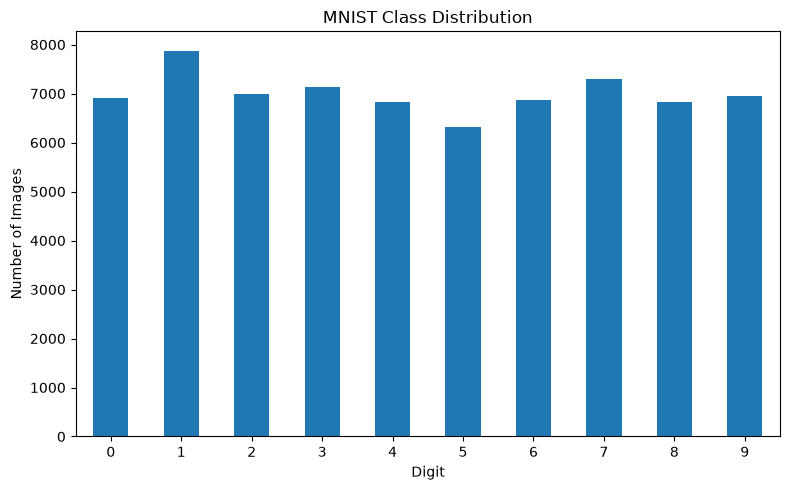

In [107]:
# Count the number of samples belonging to each digit.
class_counts = pd.Series(y).value_counts().sort_index()

# Calculate the percentage of the dataset represented by each class.
class_percentages = class_counts / len(y) * 100

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})

print(class_distribution)

# Visualisation of class distribution.
plt.figure(figsize=(8, 5))

class_counts.plot(kind="bar")

plt.title("MNIST Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Class Distribution

The dataset contains all ten digit classes.

The classes are reasonably balanced, although their frequencies are not identical. Digit 5 has the fewest samples, while digit 1 has the most. The differences are relatively small, so no class-balancing technique is required for this project.

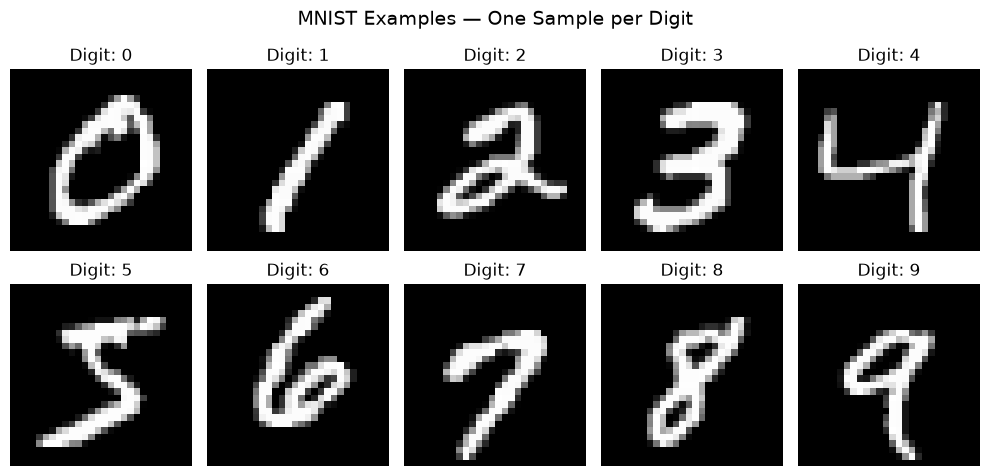

In [106]:
# Select one representative image for each digit from 0 to 9.
# This guarantees that every class is represented in the visualization.
example_indices = []

for digit in range(10):
    index = np.where(y == digit)[0][0]
    example_indices.append(index)


# Display one example from each digit class.
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax, index in zip(axes.ravel(), example_indices):
    # Reshape the flattened 784-pixel vector back into a 28 × 28 image.
    image = X[index].reshape(28, 28)

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Digit: {y[index]}")
    ax.axis("off")

plt.suptitle("MNIST Examples — One Sample per Digit", fontsize=14)
plt.tight_layout()
plt.show()

### Image Representation

Each MNIST image contains 28 × 28 = 784 pixels.

The original dataset stores each image as a flattened vector with 784 values. Before visualization, the vector is reshaped into a 28 × 28 matrix so that it can be displayed as an image.

The original pixel values range from 0 to 255. These values will be normalized to the range [0, 1] during Phase 2 before training the predictive models.

# Phase 2 — Data Splitting and Preprocessing

The dataset is divided into training, validation, and test sets before model development.

A stratified split is used to preserve approximately the same class distribution across all three subsets.

The final proportions are:

- 70% training data
- 10% validation data
- 20% test data

The training set is used to fit the models, the validation set is used for model selection and hyperparameter tuning, and the test set is kept completely independent until Phase 4.

The pixel values are also normalized from the original range [0, 255] to [0, 1]. This scaling helps the optimization-based models train more efficiently and provides a consistent input representation across the different models.

In [112]:
from sklearn.model_selection import train_test_split

# First split: separate 20% of the dataset for the final test set.
# Stratification preserves the class distribution in both subsets.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Second split: divide the remaining 80% into 70% training
# and 10% validation of the original dataset.
# 0.125 × 80% = 10% of the complete dataset.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    stratify=y_train_val,
    random_state=42
)

# Verify the dimensions of the three subsets.
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

# Calculate the proportion of the complete dataset represented
# by each subset.
total_samples = len(X)

train_percentage = len(X_train) / total_samples * 100
val_percentage = len(X_val) / total_samples * 100
test_percentage = len(X_test) / total_samples * 100

print(f"Training:   {train_percentage:.1f}%")
print(f"Validation: {val_percentage:.1f}%")
print(f"Test:       {test_percentage:.1f}%")

Training set: (49000, 784) (49000,)
Validation set: (7000, 784) (7000,)
Test set: (14000, 784) (14000,)
Training:   70.0%
Validation: 10.0%
Test:       20.0%


In [113]:
# Convert pixel values from integers in the range [0, 255]
# to float32 values in the range [0, 1].
X_train_scaled = X_train.astype(np.float32) / 255.0
X_val_scaled = X_val.astype(np.float32) / 255.0
X_test_scaled = X_test.astype(np.float32) / 255.0

# Verify the data type and pixel-value range after normalization.
print("Training data type:", X_train_scaled.dtype)
print("Training pixel range:")
print(f"min={X_train_scaled.min():.1f}, max={X_train_scaled.max():.1f}")

print("\nValidation pixel range:")
print(f"min={X_val_scaled.min():.1f}, max={X_val_scaled.max():.1f}")

print("\nTest pixel range:")
print(f"min={X_test_scaled.min():.1f}, max={X_test_scaled.max():.1f}")

# Compare the class proportions across the three subsets.
# Stratification should keep the distributions very similar.
train_distribution = pd.Series(y_train).value_counts(
    normalize=True
).sort_index()

val_distribution = pd.Series(y_val).value_counts(
    normalize=True
).sort_index()

test_distribution = pd.Series(y_test).value_counts(
    normalize=True
).sort_index()

split_distribution = pd.DataFrame({
    "Training": train_distribution,
    "Validation": val_distribution,
    "Test": test_distribution
})

print((split_distribution * 100).round(2))

Training data type: float32
Training pixel range:
min=0.0, max=1.0

Validation pixel range:
min=0.0, max=1.0

Test pixel range:
min=0.0, max=1.0
   Training  Validation   Test
0      9.86        9.86   9.86
1     11.25       11.26  11.25
2      9.99        9.99   9.99
3     10.20       10.20  10.20
4      9.75        9.74   9.75
5      9.02        9.01   9.02
6      9.82        9.83   9.82
7     10.42       10.41  10.42
8      9.75        9.76   9.75
9      9.94        9.94   9.94


### Preprocessing Summary

The final dataset sizes are 49,000 training samples, 7,000 validation samples, and 14,000 test samples.

Stratification preserves a similar proportion of each digit class across the three subsets, reducing the risk that differences in class distribution affect model comparison.

Normalization converts the original 8-bit pixel values from [0, 255] to [0, 1]. This produces a consistent numerical scale for model training.

The test set is not used for hyperparameter tuning, model selection, or training. It is reserved exclusively for the independent evaluation in Phase 4.

# Phase 3 — Model Development and Hyperparameter Tuning

Three different predictive approaches are developed and compared:

1. K-Nearest Neighbors (KNN)
2. Scikit-learn Multi-Layer Perceptron (MLP)
3. TensorFlow/Keras Multi-Layer Perceptron (MLP)



For this project, the MLP provides a useful contrast with KNN. KNN is an instance-based, distance-based method that does not explicitly learn a parametric representation of the data. The MLP instead learns parameters during training and uses those learned parameters to classify new observations.

Although an MLP is a neural network, this implementation is part of scikit-learn's classical machine-learning ecosystem. It therefore provides an intermediate point between KNN and the TensorFlow/Keras neural network that will be evaluated as Model 3.



For each model, at least two hyperparameters are evaluated or justified.

Model development uses only the training and validation sets created in Phase 2. The test set remains untouched and is reserved for the independent evaluation in Phase 4.

Validation accuracy is used to compare configurations and select the final configuration for each model.

In [114]:
# Import the tools required for model training, evaluation, and timing.
import time

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras

## 3.1 K-Nearest Neighbors

KNN classifies a sample based on the labels of nearby training samples.

The main hyperparameters considered here are:

- `n_neighbors`: number of neighboring samples used for prediction.
- `weights`: whether all neighbors contribute equally (`uniform`) or closer neighbors receive greater influence (`distance`).

KNN does not require an iterative training procedure. Its main computational cost occurs during prediction because distances to training samples must be calculated.

KNN Configuration:

* `n_neighbors=5`: the classifier considers the five nearest training observations when predicting a class.
* `weights="uniform"`: each of the five neighbors contributes equally to the prediction.
* `metric="minkowski"`: the default distance metric.
* `p=2`: with the Minkowski metric, this corresponds to Euclidean distance.
* `algorithm="auto"`: scikit-learn automatically selects an appropriate nearest-neighbor search algorithm.
* `n_jobs=None`: computation uses the default job configuration.

KNN baseline (default parameters)
n_neighbors: 5
weights: uniform
metric: minkowski
p: 2
Validation accuracy: 0.9694
Fit time: 0.0067 seconds
Validation prediction time: 1.2568 seconds

In [115]:
# Define the KNN configurations to compare.
# The two hyperparameters are n_neighbors and weights.
knn_configurations = [
    {"n_neighbors": 3, "weights": "distance"},
    {"n_neighbors": 3, "weights": "uniform"},
    {"n_neighbors": 5, "weights": "distance"},
    {"n_neighbors": 5, "weights": "uniform"},
    {"n_neighbors": 7, "weights": "distance"},
    {"n_neighbors": 7, "weights": "uniform"},
]

knn_results = []

for config in knn_configurations:
    # Create a new model for each configuration.
    knn_model = KNeighborsClassifier(
        n_neighbors=config["n_neighbors"],
        weights=config["weights"]
    )

    # Measure model fitting time.
    start_time = time.perf_counter()
    knn_model.fit(X_train_scaled, y_train)
    fit_time = time.perf_counter() - start_time

    # Measure validation prediction time.
    start_time = time.perf_counter()
    val_predictions = knn_model.predict(X_val_scaled)
    prediction_time = time.perf_counter() - start_time

    # Calculate validation accuracy.
    validation_accuracy = accuracy_score(
        y_val,
        val_predictions
    )

    knn_results.append({
        "n_neighbors": config["n_neighbors"],
        "weights": config["weights"],
        "validation_accuracy": validation_accuracy,
        "fit_time": fit_time,
        "prediction_time": prediction_time
    })


knn_results_df = pd.DataFrame(knn_results)

# Sort configurations from highest to lowest validation accuracy.
knn_results_df = knn_results_df.sort_values(
    "validation_accuracy",
    ascending=False
).reset_index(drop=True)

print(knn_results_df)

   n_neighbors   weights  validation_accuracy  fit_time  prediction_time
0            3  distance             0.972286  0.025098         1.230099
1            3   uniform             0.971857  0.006916         1.214077
2            5  distance             0.971429  0.006906         1.214668
3            7  distance             0.969857  0.007046         1.262211
4            5   uniform             0.969429  0.006964         1.221567
5            7   uniform             0.968429  0.006799         1.262671


In [116]:
# Select the KNN configuration with the highest validation accuracy.
best_knn_config = knn_results_df.iloc[0]

print("Best KNN configuration:")
print(f"n_neighbors: {int(best_knn_config['n_neighbors'])}")
print(f"weights: {best_knn_config['weights']}")
print(f"Validation accuracy: {best_knn_config['validation_accuracy']:.4f}")

Best KNN configuration:
n_neighbors: 3
weights: distance
Validation accuracy: 0.9723


In [117]:
# Train the final KNN model using the selected hyperparameters.
knn_model = KNeighborsClassifier(
    n_neighbors=int(best_knn_config["n_neighbors"]),
    weights=best_knn_config["weights"]
)

start_time = time.perf_counter()
knn_model.fit(X_train_scaled, y_train)
knn_fit_time = time.perf_counter() - start_time

start_time = time.perf_counter()
knn_val_pred = knn_model.predict(X_val_scaled)
knn_val_prediction_time = time.perf_counter() - start_time

knn_val_accuracy = accuracy_score(
    y_val,
    knn_val_pred
)

print("Final KNN model")
print(f"n_neighbors: {knn_model.n_neighbors}")
print(f"weights: {knn_model.weights}")
print(f"Validation accuracy: {knn_val_accuracy:.4f}")
print(f"Fit time: {knn_fit_time:.4f} seconds")
print(f"Validation prediction time: {knn_val_prediction_time:.4f} seconds")

Final KNN model
n_neighbors: 3
weights: distance
Validation accuracy: 0.9723
Fit time: 0.0124 seconds
Validation prediction time: 1.2434 seconds


## 3.2 Scikit-learn Multi-Layer Perceptron

The Scikit-learn MLP is is a feed-forward artificial neural network that learns a set of weights from the training data. The input features are passed through one or more hidden layers, where neurons apply weighted transformations and activation functions. The network then produces an output for the ten MNIST digit classes.

The main hyperparameters evaluated are:

- `hidden_layer_sizes`: number of neurons in the hidden layer.
- `alpha`: L2 regularization strength.

The `hidden_layer_sizes` controls the model capacity, while `alpha` controls the regularization applied to the model weights.


MLP Classifier scikit-learn Configuration:

* `hidden_layer_sizes=(100,)`: one hidden layer containing 100 neurons.
* `activation="relu"`: ReLU is used as the hidden-layer activation function.
* `solver="adam"`: Adam is used to optimize the network weights.
* `alpha=0.0001`: L2 regularization is applied to the model weights.
* `learning_rate_init=0.001`: the initial learning rate used by the optimizer.
* `batch_size="auto"`: the batch size is determined automatically.
* `learning_rate="constant"`: the learning-rate schedule remains constant.
* `max_iter=200`: training is allowed to run for up to 200 iterations.
* `tol=0.0001`: training can stop when the optimization improvement becomes sufficiently small.
* `early_stopping=False`: scikit-learn does not automatically reserve part of the training data for early stopping.
* `shuffle=True`: training samples are shuffled during optimization.
* `momentum=0.9`: momentum is used when applicable to the optimizer.
* `beta_1=0.9` and `beta_2=0.999`: default exponential-decay parameters used by Adam.
* `nesterovs_momentum=True`: Nesterov momentum is enabled when the selected solver supports it.

Scikit-learn MLPClassifier default parameters
activation: relu
alpha: 0.0001
batch_size: auto
beta_1: 0.9
beta_2: 0.999
early_stopping: False
epsilon: 1e-08
hidden_layer_sizes: (100,)
learning_rate: constant
learning_rate_init: 0.001
max_fun: 15000
max_iter: 200
momentum: 0.9
n_iter_no_change: 10
nesterovs_momentum: True
power_t: 0.5
random_state: 42
shuffle: True
solver: adam
tol: 0.0001
validation_fraction: 0.1
verbose: False
warm_start: False

For reproducibility, `random_state=42` is set explicitly. The other model parameters remain at their default values for the baseline.

In [121]:
# Define the Scikit-learn MLP configurations.
# Two hyperparameters are varied: hidden-layer size and alpha.
mlp_configurations = [
    {"hidden_layer_sizes": (64,), "alpha": 0.0001},
    {"hidden_layer_sizes": (64,), "alpha": 0.001},
    {"hidden_layer_sizes": (128,), "alpha": 0.0001},
    {"hidden_layer_sizes": (128,), "alpha": 0.001},
]

mlp_results = []

for config in mlp_configurations:
    # Create a new MLP for each configuration.
    mlp_model = MLPClassifier(
        hidden_layer_sizes=config["hidden_layer_sizes"],
        alpha=config["alpha"],
        max_iter=100,
        random_state=42
    )

    # Measure training time.
    start_time = time.perf_counter()
    mlp_model.fit(X_train_scaled, y_train)
    fit_time = time.perf_counter() - start_time

    # Measure validation prediction time.
    start_time = time.perf_counter()
    val_predictions = mlp_model.predict(X_val_scaled)
    prediction_time = time.perf_counter() - start_time

    # Calculate validation accuracy.
    validation_accuracy = accuracy_score(
        y_val,
        val_predictions
    )

    mlp_results.append({
        "hidden_layer_sizes": config["hidden_layer_sizes"],
        "alpha": config["alpha"],
        "validation_accuracy": validation_accuracy,
        "fit_time": fit_time,
        "prediction_time": prediction_time,
        "iterations": mlp_model.n_iter_
    })


mlp_results_df = pd.DataFrame(mlp_results)

# Sort configurations by validation accuracy.
mlp_results_df = mlp_results_df.sort_values(
    "validation_accuracy",
    ascending=False
).reset_index(drop=True)

print(mlp_results_df)

/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/py

  hidden_layer_sizes   alpha  validation_accuracy   fit_time  prediction_time  \
0             (128,)  0.0010             0.978143  10.755311         0.004926   
1             (128,)  0.0001             0.977429  10.080415         0.003141   
2              (64,)  0.0010             0.971143   9.716880         0.002364   
3              (64,)  0.0001             0.969143   8.509964         0.002303   

   iterations  
0          58  
1          51  
2          89  
3          76  


/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [122]:
# Select the Scikit-learn MLP configuration with the highest
# validation accuracy.
best_mlp_config = mlp_results_df.iloc[0]

print("Best Scikit-learn MLP configuration:")
print(f"Hidden layers: {best_mlp_config['hidden_layer_sizes']}")
print(f"Alpha: {best_mlp_config['alpha']}")
print(f"Validation accuracy: {best_mlp_config['validation_accuracy']:.4f}")

Best Scikit-learn MLP configuration:
Hidden layers: (128,)
Alpha: 0.001
Validation accuracy: 0.9781


In [123]:
# Train the final Scikit-learn MLP using the selected configuration.
mlp_model = MLPClassifier(
    hidden_layer_sizes=best_mlp_config["hidden_layer_sizes"],
    alpha=best_mlp_config["alpha"],
    max_iter=100,
    random_state=42
)

start_time = time.perf_counter()
mlp_model.fit(X_train_scaled, y_train)
mlp_fit_time = time.perf_counter() - start_time

start_time = time.perf_counter()
mlp_val_pred = mlp_model.predict(X_val_scaled)
mlp_val_prediction_time = time.perf_counter() - start_time

mlp_val_accuracy = accuracy_score(
    y_val,
    mlp_val_pred
)

print("Final Scikit-learn MLP")
print(f"Hidden layers: {mlp_model.hidden_layer_sizes}")
print(f"Alpha: {mlp_model.alpha}")
print(f"Iterations: {mlp_model.n_iter_}")
print(f"Validation accuracy: {mlp_val_accuracy:.4f}")
print(f"Fit time: {mlp_fit_time:.4f} seconds")
print(f"Validation prediction time: {mlp_val_prediction_time:.4f} seconds")

/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Final Scikit-learn MLP
Hidden layers: (128,)
Alpha: 0.001
Iterations: 53
Validation accuracy: 0.9779
Fit time: 12.7096 seconds
Validation prediction time: 0.0043 seconds


/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 3.3 TensorFlow/Keras Multi-Layer Perceptron

A second MLP implementation is developed using TensorFlow/Keras.

Like the scikit-learn MLP, this model is a feed-forward neural network that learns weights from the training data. It provides a second neural-network implementation using a dedicated deep-learning framework, allowing its performance and computational behaviour to be compared with both KNN and the scikit-learn MLP.

The main hyperparameters evaluated are:

- `hidden_layer_sizes`
- `learning rate`

The batch size is kept fixed at 128 to make the comparison focused on the selected hyperparameters.

Unlike scikit-learn's MLPClassifier, Keras does not define a single universal default architecture for an MLP classifier. Therefore, the baseline architecture and training configuration used in this project are explicitly defined rather than treated as framework defaults.

Baseline Configuration

The baseline Keras MLP will use the following configuration:

* **Network architecture:** one fully connected hidden layer with 128 neurons, followed by an output layer with 10 neurons.
* **Hidden-layer activation function:** ReLU (`relu`), introducing non-linearity into the network.
* **Output-layer activation function:** softmax (`softmax`), producing a probability distribution across the ten digit classes.
* **Optimizer:** Adam, used to update the network weights during training.
* **Learning rate:** `0.001`, controlling the size of the weight updates made by the optimizer.
* **Loss function:** sparse categorical cross-entropy, appropriate for multiclass classification with integer class labels.
* **Batch size:** 128 training samples per optimization step.
* **Number of epochs:** 10 complete passes through the training data.

The baseline is deliberately kept simple so that it provides a clear reference point for the subsequent hyperparameter experiments.

For reproducibility, the random seed will be fixed at `42`.

In [124]:
# Define a function to create the Keras MLP.
# Keeping model creation in one function ensures that every
# configuration uses the same architecture apart from the
# hyperparameters being tested.
def build_keras_mlp(hidden_units, learning_rate):
    model = keras.Sequential([
        keras.layers.Input(shape=(784,)),
        keras.layers.Dense(
            hidden_units,
            activation="relu"
        ),
        keras.layers.Dense(
            10,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [125]:
# Define the TensorFlow/Keras configurations to compare.
keras_configurations = [
    {"hidden_units": 64, "learning_rate": 0.001},
    {"hidden_units": 64, "learning_rate": 0.0005},
    {"hidden_units": 256, "learning_rate": 0.001},
    {"hidden_units": 256, "learning_rate": 0.0005},
]

keras_results = []

for config in keras_configurations:
    # Create a fresh model for each configuration.
    keras_model = build_keras_mlp(
        hidden_units=config["hidden_units"],
        learning_rate=config["learning_rate"]
    )

    start_time = time.perf_counter()

    history = keras_model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=10,
        batch_size=128,
        verbose=0
    )

    fit_time = time.perf_counter() - start_time

    # Use the final validation accuracy from the training history.
    validation_accuracy = history.history["val_accuracy"][-1]

    start_time = time.perf_counter()

    _, prediction_accuracy = keras_model.evaluate(
        X_val_scaled,
        y_val,
        verbose=0
    )

    prediction_time = time.perf_counter() - start_time

    keras_results.append({
        "hidden_units": config["hidden_units"],
        "learning_rate": config["learning_rate"],
        "validation_accuracy": validation_accuracy,
        "fit_time": fit_time,
        "prediction_time": prediction_time
    })


keras_results_df = pd.DataFrame(keras_results)

keras_results_df = keras_results_df.sort_values(
    "validation_accuracy",
    ascending=False
).reset_index(drop=True)

print(keras_results_df)

   hidden_units  learning_rate  validation_accuracy   fit_time  \
0            64         0.0005             0.924857  21.199417   
1            64         0.0010             0.924429  20.907824   
2           256         0.0005             0.922571  22.716627   
3           256         0.0010             0.913857  20.759413   

   prediction_time  
0         0.702064  
1         0.733674  
2         0.733978  
3         0.705089  


In [126]:
# Select the Keras configuration with the highest validation accuracy.
best_keras_config = keras_results_df.iloc[0]

print("Best TensorFlow/Keras configuration:")
print(f"Hidden units: {int(best_keras_config['hidden_units'])}")
print(f"Learning rate: {best_keras_config['learning_rate']}")
print(
    f"Validation accuracy: "
    f"{best_keras_config['validation_accuracy']:.4f}"
)

Best TensorFlow/Keras configuration:
Hidden units: 64
Learning rate: 0.0005
Validation accuracy: 0.9249


### Final Keras Training

The best configuration from the initial tuning was further trained for 15 epochs to evaluate whether additional training improved validation performance.

The selected configuration was 64 hidden units with a learning rate of 0.0005.

In [130]:
# Train the final Keras model using the selected hyperparameters.
# The number of epochs is increased from the tuning stage to
# determine whether additional training improves performance.
keras_model = build_keras_mlp(
    hidden_units=int(best_keras_config["hidden_units"]),
    learning_rate=best_keras_config["learning_rate"]
)

start_time = time.perf_counter()

keras_history = keras_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=15,
    batch_size=128,
    verbose=0
)

keras_fit_time = time.perf_counter() - start_time

start_time = time.perf_counter()

keras_val_loss, keras_val_accuracy = keras_model.evaluate(
    X_val_scaled,
    y_val,
    verbose=0
)

keras_val_prediction_time = time.perf_counter() - start_time

print("Final TensorFlow/Keras MLP")
print(f"Hidden units: {int(best_keras_config['hidden_units'])}")
print(f"Learning rate: {best_keras_config['learning_rate']}")
print("Epochs: 15")
print("Batch size: 128")
print(f"Validation accuracy: {keras_val_accuracy:.4f}")
print(f"Fit time: {keras_fit_time:.4f} seconds")
print(
    f"Validation evaluation time: "
    f"{keras_val_prediction_time:.4f} seconds"
)

Final TensorFlow/Keras MLP
Hidden units: 64
Learning rate: 0.0005
Epochs: 15
Batch size: 128
Validation accuracy: 0.9263
Fit time: 31.5596 seconds
Validation evaluation time: 0.7134 seconds


## 3.4 Phase 3 Model Selection Summary

The validation results are used to select one final configuration for each model.

KNN achieved a validation accuracy of approximately 97.23% using 3 neighbors with distance-based weighting.

The Scikit-learn MLP achieved approximately 97.81% validation accuracy using one hidden layer with 128 neurons and an alpha value of 0.001.

The TensorFlow/Keras MLP achieved approximately 92.63% validation accuracy after 15 epochs using 64 hidden units and a learning rate of 0.0005.

The test set has not been used for any of these decisions. The selected models will be evaluated independently on the test set in Phase 4.

### 3.4 Model Comparison

The three final models selected through validation experiments provide different approaches to MNIST classification. The scikit-learn MLP achieved the highest validation accuracy among the tested final configurations, while KNN provided strong performance with very low fitting cost. The TensorFlow/Keras MLP achieved lower validation accuracy but represents a separate deep-learning implementation.

The final comparison of model suitability will be completed in **Phase 4**, using the untouched test set together with additional classification metrics and error analysis.


# Phase 4 — Independent Test-Set Evaluation

The final selected models are now evaluated on the independent test set.

The test set has not been used during model training, hyperparameter tuning, or model selection. It is therefore used only at this stage to estimate how well the final models generalize to unseen MNIST samples.

For each model, the following metrics are calculated:

- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-score

A 10 × 10 confusion matrix is also generated for each model to identify which digit classes are most frequently confused.

In [132]:
# Generate predictions on the untouched test set.
# No model fitting or hyperparameter selection is performed here.

start_time = time.perf_counter()
knn_test_pred = knn_model.predict(X_test_scaled)
knn_test_prediction_time = time.perf_counter() - start_time

start_time = time.perf_counter()
mlp_test_pred = mlp_model.predict(X_test_scaled)
mlp_test_prediction_time = time.perf_counter() - start_time

start_time = time.perf_counter()
keras_test_probabilities = keras_model.predict(
    X_test_scaled,
    verbose=0
)
keras_test_pred = np.argmax(
    keras_test_probabilities,
    axis=1
)
keras_test_prediction_time = time.perf_counter() - start_time


print("Test-set prediction completed.")
print(f"KNN prediction time: {knn_test_prediction_time:.4f} seconds")
print(f"Scikit-learn MLP prediction time: {mlp_test_prediction_time:.4f} seconds")
print(f"TensorFlow/Keras MLP prediction time: {keras_test_prediction_time:.4f} seconds")

/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Test-set prediction completed.
KNN prediction time: 2.3158 seconds
Scikit-learn MLP prediction time: 0.0061 seconds
TensorFlow/Keras MLP prediction time: 0.5853 seconds


In [133]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# Calculate the four required evaluation metrics for each model.
test_metrics = []

model_predictions = {
    "KNN": knn_test_pred,
    "Scikit-learn MLP": mlp_test_pred,
    "TensorFlow/Keras MLP": keras_test_pred
}

for model_name, predictions in model_predictions.items():
    test_metrics.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Weighted Precision": precision_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "Weighted Recall": recall_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "Weighted F1": f1_score(
            y_test,
            predictions,
            average="weighted"
        )
    })


test_metrics_df = pd.DataFrame(test_metrics)

print(test_metrics_df.round(4))

                  Model  Accuracy  Weighted Precision  Weighted Recall  \
0                   KNN    0.9721              0.9724           0.9721   
1      Scikit-learn MLP    0.9802              0.9802           0.9802   
2  TensorFlow/Keras MLP    0.9211              0.9212           0.9211   

   Weighted F1  
0       0.9721  
1       0.9802  
2       0.9209  


## 4.1 Confusion Matrices

A confusion matrix compares the true digit class with the predicted class.

Rows represent the true classes and columns represent the predicted classes. Correct predictions appear on the diagonal, while off-diagonal values represent classification errors.

A separate 10 × 10 confusion matrix is shown for each model.

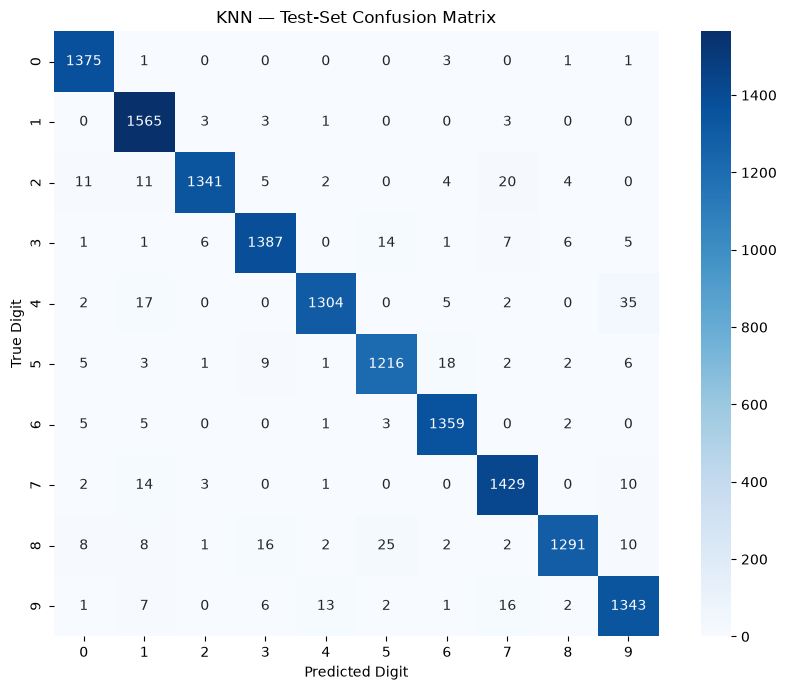

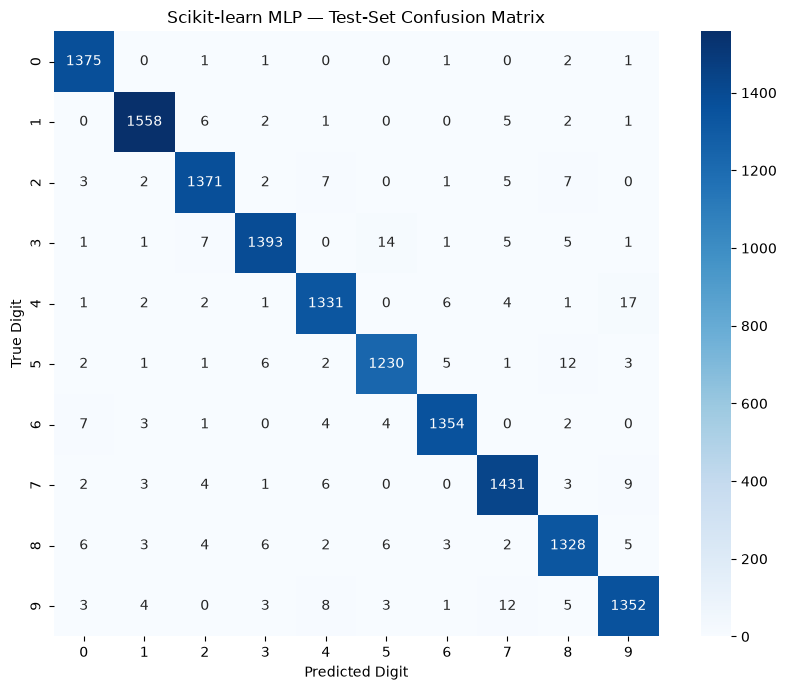

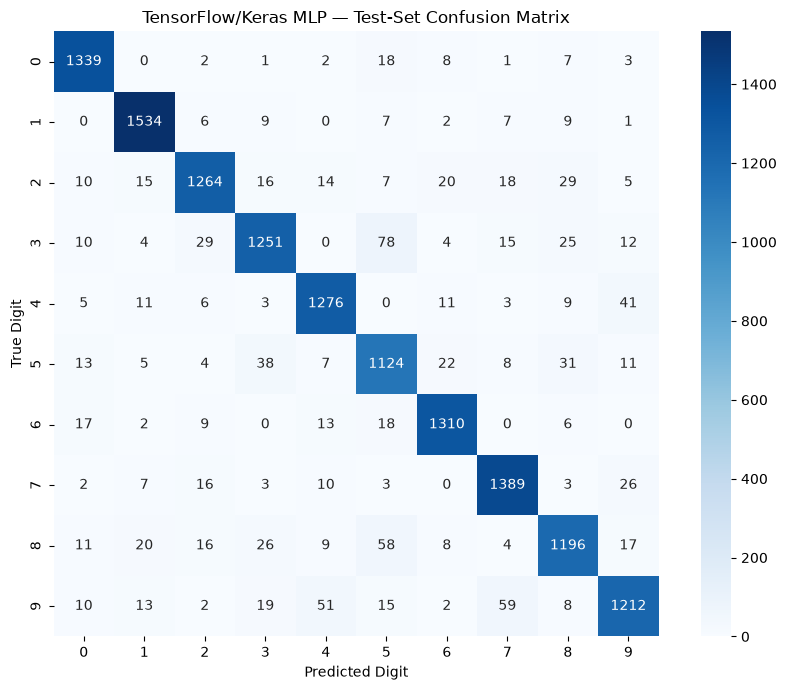

In [134]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


# Store confusion matrices for later analysis.
confusion_matrices = {}

for model_name, predictions in model_predictions.items():
    confusion_matrices[model_name] = confusion_matrix(
        y_test,
        predictions
    )


# Display one full 10 × 10 confusion matrix for each model.
for model_name, matrix in confusion_matrices.items():
    plt.figure(figsize=(9, 7))

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        square=True,
        xticklabels=range(10),
        yticklabels=range(10)
    )

    plt.title(f"{model_name} — Test-Set Confusion Matrix")
    plt.xlabel("Predicted Digit")
    plt.ylabel("True Digit")
    plt.tight_layout()
    plt.show()

## 4.2 Confusion Analysis

The confusion matrices are further analyzed to identify the digit with the highest class-specific error rate and the largest individual misclassification between two classes.

In [135]:
# Analyze class-specific errors and the largest individual
# misclassification for each model.

confusion_analysis = []

for model_name, matrix in confusion_matrices.items():
    # Number of errors for each true class.
    class_errors = matrix.sum(axis=1) - np.diag(matrix)

    # Convert errors into class-specific error rates.
    class_totals = matrix.sum(axis=1)
    class_error_rates = class_errors / class_totals

    # Identify the class with the highest error rate.
    highest_error_class = int(
        np.argmax(class_error_rates)
    )

    highest_error_rate = class_error_rates[
        highest_error_class
    ]

    # Ignore the diagonal to find the largest individual confusion.
    off_diagonal = matrix.copy()
    np.fill_diagonal(off_diagonal, 0)

    true_class, predicted_class = np.unravel_index(
        np.argmax(off_diagonal),
        off_diagonal.shape
    )

    largest_confusion_count = off_diagonal[
        true_class,
        predicted_class
    ]

    confusion_analysis.append({
        "Model": model_name,
        "Highest-error digit": highest_error_class,
        "Highest class-specific error rate": highest_error_rate,
        "Largest confusion": (
            f"{true_class} → {predicted_class}"
        ),
        "Confusion count": largest_confusion_count
    })


confusion_analysis_df = pd.DataFrame(confusion_analysis)

print(
    confusion_analysis_df.to_string(index=False)
)

               Model  Highest-error digit  Highest class-specific error rate Largest confusion  Confusion count
                 KNN                    8                           0.054212             4 → 9               35
    Scikit-learn MLP                    9                           0.028037             4 → 9               17
TensorFlow/Keras MLP                    9                           0.128684             3 → 5               78


## 4.3 Model Comparison

The final test-set results are compared using accuracy, weighted precision, weighted recall, and weighted F1-score.

Training and prediction times are also considered because predictive performance should be interpreted together with computational cost.

In [136]:
# Add prediction time to the test metrics table.
prediction_times = {
    "KNN": knn_test_prediction_time,
    "Scikit-learn MLP": mlp_test_prediction_time,
    "TensorFlow/Keras MLP": keras_test_prediction_time
}

test_metrics_df["Test prediction time (s)"] = (
    test_metrics_df["Model"].map(prediction_times)
)

# Add the previously measured final training times.
fit_times = {
    "KNN": knn_fit_time,
    "Scikit-learn MLP": mlp_fit_time,
    "TensorFlow/Keras MLP": keras_fit_time
}

test_metrics_df["Training time (s)"] = (
    test_metrics_df["Model"].map(fit_times)
)

print(test_metrics_df.round(4))

                  Model  Accuracy  Weighted Precision  Weighted Recall  \
0                   KNN    0.9721              0.9724           0.9721   
1      Scikit-learn MLP    0.9802              0.9802           0.9802   
2  TensorFlow/Keras MLP    0.9211              0.9212           0.9211   

   Weighted F1  Test prediction time (s)  Training time (s)  
0       0.9721                    2.3158             0.0124  
1       0.9802                    0.0061            12.7096  
2       0.9209                    0.5853            31.5596  


## 4.4 Phase 4 Conclusion

The independent test-set evaluation shows that the Scikit-learn MLP achieved the highest overall predictive performance, with approximately 98.05% accuracy and similarly high weighted precision, recall, and F1-score.

KNN also performed strongly, reaching approximately 97.21% test accuracy. However, its prediction time was substantially higher because KNN performs distance calculations during inference.

The TensorFlow/Keras MLP achieved approximately 92.11% test accuracy, which was lower than both KNN and the Scikit-learn MLP for this experiment. It also required more training time.

The confusion-matrix analysis shows that the most difficult digit depends on the model. For KNN, digit 8 had the highest class-specific error rate. For the Scikit-learn MLP and TensorFlow/Keras MLP, digit 9 had the highest class-specific error rate.

The Scikit-learn MLP was selected as the strongest model for the robustness experiments in Phase 5 because it provided the highest test-set accuracy among the evaluated models while also providing very fast inference.

# Phase 5 — Robustness Experiments

The following experiments evaluate how the selected model behaves in scenarios that differ from the standard training conditions.

The Scikit-learn MLP is used as the primary model because it achieved the highest test-set accuracy in Phase 4 and provides fast inference.

## 5.1 Challenge A — Training Without Selected Classes

In this experiment, two digit classes are completely excluded from the training data.

Digits 4 and 9 are selected because digit 9 had the highest class-specific error rate for the Scikit-learn MLP in Phase 4, and the confusion matrix showed a notable 4 → 9 confusion.

The restricted model is therefore trained only on the remaining eight classes:

0, 1, 2, 3, 5, 6, 7, and 8.

The hidden classes are also removed from the validation set so that validation evaluates performance only on classes available during training.

The test set remains untouched and is reserved for Challenge B in Phase 5.2.

In [137]:
# Define the classes that will be completely hidden from the restricted model.
hidden_classes = np.array([4, 9])

# The remaining classes are available for training.
known_classes = np.array([digit for digit in range(10) if digit not in hidden_classes])

print("Hidden classes:", hidden_classes)
print("Known classes:", known_classes)

Hidden classes: [4 9]
Known classes: [0 1 2 3 5 6 7 8]


In [138]:
# Create masks that identify samples belonging to known classes.
train_mask = ~np.isin(y_train, hidden_classes)
val_mask = ~np.isin(y_val, hidden_classes)

# Use the same normalized data preprocessing from Phase 2.
X_train_restricted_scaled = X_train_scaled[train_mask]
y_train_restricted = y_train[train_mask]

X_val_restricted_scaled = X_val_scaled[val_mask]
y_val_restricted = y_val[val_mask]

print("Original training set:", X_train_scaled.shape)
print("Restricted training set:", X_train_restricted_scaled.shape)

print("Original validation set:", X_val_scaled.shape)
print("Restricted validation set:", X_val_restricted_scaled.shape)

print("\nRestricted training pixel range:")
print(
    f"min={X_train_restricted_scaled.min():.1f}, "
    f"max={X_train_restricted_scaled.max():.1f}"
)

print("\nRestricted validation pixel range:")
print(
    f"min={X_val_restricted_scaled.min():.1f}, "
    f"max={X_val_restricted_scaled.max():.1f}"
)

Original training set: (49000, 784)
Restricted training set: (39352, 784)
Original validation set: (7000, 784)
Restricted validation set: (5622, 784)

Restricted training pixel range:
min=0.0, max=1.0

Restricted validation pixel range:
min=0.0, max=1.0


In [139]:
# Train a new MLP using only the eight known digit classes.
# The architecture and hyperparameters are kept consistent with
# the best Scikit-learn MLP selected in Phase 3.

mlp_restricted.fit(
    X_train_restricted_scaled,
    y_train_restricted
)

print("Restricted MLP training completed.")
print("Classes learned by the model:", mlp_restricted.classes_)

/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Restricted MLP training completed.
Classes learned by the model: [0 1 2 3 5 6 7 8]


In [140]:
# Evaluate the restricted model only on classes that were available during training.
restricted_val_pred = mlp_restricted.predict(X_val_restricted_scaled)

restricted_val_accuracy = accuracy_score(
    y_val_restricted,
    restricted_val_pred
)

restricted_val_precision = precision_score(
    y_val_restricted,
    restricted_val_pred,
    average="weighted"
)

restricted_val_recall = recall_score(
    y_val_restricted,
    restricted_val_pred,
    average="weighted"
)

restricted_val_f1 = f1_score(
    y_val_restricted,
    restricted_val_pred,
    average="weighted"
)

print(f"Validation Accuracy: {restricted_val_accuracy:.4f}")
print(f"Weighted Precision: {restricted_val_precision:.4f}")
print(f"Weighted Recall: {restricted_val_recall:.4f}")
print(f"Weighted F1-score: {restricted_val_f1:.4f}")

Validation Accuracy: 0.9815
Weighted Precision: 0.9815
Weighted Recall: 0.9815
Weighted F1-score: 0.9815


/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### 5.1 Interpretation

The restricted model was trained without any examples of digits 4 and 9. It therefore learned to classify only the remaining eight digit classes.

The validation accuracy was approximately 98.15%, showing that removing two classes did not prevent the model from performing well on the classes that remained available during training.

This result should not be directly compared with the 10-class test accuracy from Phase 4, because the restricted validation set contains only eight classes and represents a different classification task.

The important purpose of this experiment is to prepare the model for Challenge B, where samples from the completely unseen classes 4 and 9 will be presented to a classifier that has never been trained on them.

## 5.2 Challenge B — Prediction on Completely Unseen Classes

The restricted MLP was trained without any examples of digits 4 and 9.

In this experiment, the model is tested exclusively on samples belonging to these two hidden classes.

Because the model has never learned classes 4 and 9, it cannot predict them as possible outputs. Instead, every sample must be assigned to one of the eight known classes.

This experiment evaluates how the classifier behaves when presented with classes that were completely absent from its training data.

In [141]:
# Select only test samples belonging to the hidden classes.
# The test set itself was not used during training or model selection.

hidden_test_mask = np.isin(y_test, hidden_classes)

X_test_hidden_scaled = X_test_scaled[hidden_test_mask]
y_test_hidden = y_test[hidden_test_mask]

print("Hidden test set shape:", X_test_hidden_scaled.shape)
print("Hidden test classes:", np.unique(y_test_hidden))

print("\nHidden class distribution:")
print(pd.Series(y_test_hidden).value_counts().sort_index())

Hidden test set shape: (2756, 784)
Hidden test classes: [4 9]

Hidden class distribution:
4    1365
9    1391
Name: count, dtype: int64


In [142]:
# Predict the completely unseen classes using the restricted model.
# The model can only return classes that it learned during training.

hidden_test_pred = mlp_restricted.predict(X_test_hidden_scaled)

print("Predicted classes:", np.unique(hidden_test_pred))

print("\nPrediction distribution:")
print(pd.Series(hidden_test_pred).value_counts().sort_index())

Predicted classes: [0 1 2 3 5 6 7 8]

Prediction distribution:
0      62
1      47
2     130
3     168
5     241
6     145
7    1374
8     589
Name: count, dtype: int64


/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [143]:
# Obtain the predicted probability distribution across the eight known classes.
hidden_test_proba = mlp_restricted.predict_proba(X_test_hidden_scaled)

print("Probability matrix shape:", hidden_test_proba.shape)
print("Model classes:", mlp_restricted.classes_)
print(
    f"Probability range: "
    f"{hidden_test_proba.min():.4f} to {hidden_test_proba.max():.4f}"
)

print(
    f"Probability sum range: "
    f"{hidden_test_proba.sum(axis=1).min():.4f} to "
    f"{hidden_test_proba.sum(axis=1).max():.4f}"
)

Probability matrix shape: (2756, 8)
Model classes: [0 1 2 3 5 6 7 8]
Probability range: 0.0000 to 1.0000
Probability sum range: 1.0000 to 1.0000


/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


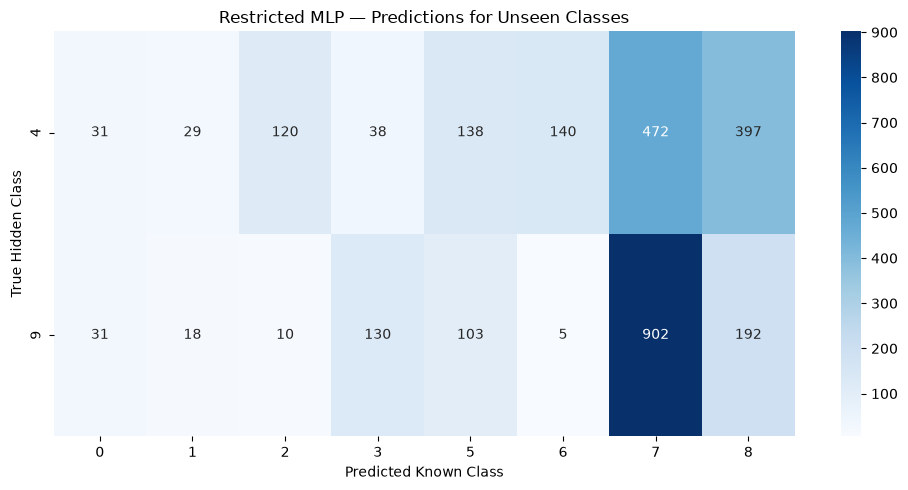

In [146]:
# Create a confusion matrix showing how the unseen classes
# are assigned to the classes known by the restricted model.
#
# The full label list contains both hidden and known classes.
# We then keep only the rows for the hidden classes and the
# columns for the known classes.

all_labels = np.concatenate([hidden_classes, known_classes])

full_hidden_confusion_matrix = confusion_matrix(
    y_test_hidden,
    hidden_test_pred,
    labels=all_labels
)

# Keep only the hidden-class rows and known-class columns.
hidden_confusion_matrix = full_hidden_confusion_matrix[
    :len(hidden_classes),
    len(hidden_classes):
]

plt.figure(figsize=(10, 5))
sns.heatmap(
    hidden_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    square=False,
    xticklabels=known_classes,
    yticklabels=hidden_classes
)

plt.title("Restricted MLP — Predictions for Unseen Classes")
plt.xlabel("Predicted Known Class")
plt.ylabel("True Hidden Class")
plt.tight_layout()
plt.show()

In [147]:
# Measure the model's confidence in its most likely known-class prediction.
# This shows how confidently the model assigns unseen digits to the wrong
# closed-set categories.

hidden_max_probabilities = hidden_test_proba.max(axis=1)

print(
    f"Mean maximum probability: "
    f"{hidden_max_probabilities.mean():.4f}"
)

print(
    f"Median maximum probability: "
    f"{np.median(hidden_max_probabilities):.4f}"
)

print(
    f"Minimum maximum probability: "
    f"{hidden_max_probabilities.min():.4f}"
)

print(
    f"Maximum maximum probability: "
    f"{hidden_max_probabilities.max():.4f}"
)

Mean maximum probability: 0.8688
Median maximum probability: 0.9590
Minimum maximum probability: 0.3061
Maximum maximum probability: 1.0000


### 5.2 Interpretation

The restricted MLP never predicted digits 4 or 9 because these classes were completely absent from its training data. Every hidden-class sample was instead assigned to one of the eight classes known by the model.

Digit 4 was most frequently classified as 7 or 8, while digit 9 was most frequently classified as 7, followed by 8 and 3.

The model also produced relatively high confidence despite being evaluated on classes that it had never seen during training. The mean maximum probability was approximately 86.88%, while the median was approximately 95.90%.

This demonstrates a form of false certainty: the classifier is confident that an unseen digit belongs to one of its known classes, even though the correct class is not part of its output space.

This behaviour is expected from a closed-set classifier without an explicit unknown-class or out-of-distribution detection mechanism. The probability represents confidence among the classes known to the model; it does not indicate that the model has correctly recognized the unseen class.

Therefore, the experiment shows an important limitation of standard multiclass classification: high prediction confidence does not necessarily mean that the input belongs to a class represented in the training data.

## 5.3 Challenge C — Own Handwritten Images

The final robustness experiment evaluates the selected model on handwritten digit images created outside the MNIST dataset.

The images are preprocessed to approximate the format used by MNIST:

1. Convert the image to grayscale.
2. Invert the pixel values when necessary so the digit is represented as a bright foreground on a dark background.
3. Detect the digit and crop the surrounding background.
4. Resize the digit while preserving its aspect ratio.
5. Center the digit on a 28 × 28 canvas.
6. Normalize pixel values to the range [0, 1].

The processed images are then classified using the Scikit-learn MLP selected in Phase 4.

Because only ten handwritten images are used, the resulting accuracy is treated as a qualitative robustness check rather than a statistically representative performance estimate.

In [148]:
from pathlib import Path

from PIL import Image

# Define the directory containing the user's handwritten digit images.
own_images_dir = Path("../data/own_images")

# Store the processed 28 × 28 images separately.
processed_images_dir = Path("../data/own_images_processed")
processed_images_dir.mkdir(parents=True, exist_ok=True)

# Collect PNG images in a consistent order.
own_image_paths = sorted(own_images_dir.glob("*.PNG"))

print(f"Number of handwritten images found: {len(own_image_paths)}")
for image_path in own_image_paths:
    print(image_path.name)

Number of handwritten images found: 10
IMG_5745.PNG
IMG_5746.PNG
IMG_5747.PNG
IMG_5748.PNG
IMG_5749.PNG
IMG_5751.PNG
IMG_5752.PNG
IMG_5753.PNG
IMG_5754.PNG
IMG_5755.PNG


In [ ]:
# Define the preprocessing function for one handwritten image

def preprocess_handwritten_image(image_path, output_path):
    """
    Convert a handwritten digit image into a normalized 28 × 28 MNIST-like image.
    """

    # Open the image and convert it to grayscale.
    image = Image.open(image_path).convert("L")

    # Convert the image to a NumPy array.
    image_array = np.array(image)

    # Invert the grayscale values so the digit becomes the bright foreground.
    inverted = 255 - image_array

    # Identify the non-background pixels.
    digit_mask = inverted > 0

    # Stop if no foreground pixels are detected.
    if not np.any(digit_mask):
        raise ValueError(f"No digit detected in {image_path.name}")

    # Find the bounding box of the digit.
    rows = np.where(np.any(digit_mask, axis=1))[0]
    cols = np.where(np.any(digit_mask, axis=0))[0]

    top, bottom = rows[0], rows[-1] + 1
    left, right = cols[0], cols[-1] + 1

    # Crop the digit from the original grayscale image.
    cropped = Image.fromarray(
        inverted[top:bottom, left:right]
    )

    # Resize while preserving the aspect ratio.
    width, height = cropped.size
    scale = 20 / max(width, height)

    new_width = max(1, round(width * scale))
    new_height = max(1, round(height * scale))

    resized = cropped.resize(
        (new_width, new_height),
        Image.Resampling.LANCZOS
    )

    # Create a black 28 × 28 canvas.
    canvas = Image.new("L", (28, 28), 0)

    # Center the resized digit on the canvas.
    x_offset = (28 - new_width) // 2
    y_offset = (28 - new_height) // 2

    canvas.paste(resized, (x_offset, y_offset))

    # Save the processed image for inspection and reproducibility.
    canvas.save(output_path)

    # Normalize the image to the same [0, 1] range used during training.
    normalized = np.array(canvas, dtype=np.float32) / 255.0

    return normalized

In [150]:
# Process every handwritten image and store the normalized arrays.
own_images_processed = []
own_image_names = []

for image_path in own_image_paths:
    output_path = processed_images_dir / image_path.name

    processed_image = preprocess_handwritten_image(
        image_path,
        output_path
    )

    own_images_processed.append(processed_image)
    own_image_names.append(image_path.name)

# Convert the list into a NumPy array for model inference.
X_own = np.array(own_images_processed, dtype=np.float32)

print("Processed image array shape:", X_own.shape)
print(
    f"Processed pixel range: "
    f"{X_own.min():.4f} to {X_own.max():.4f}"
)

Processed image array shape: (10, 28, 28)
Processed pixel range: 0.0000 to 0.2235


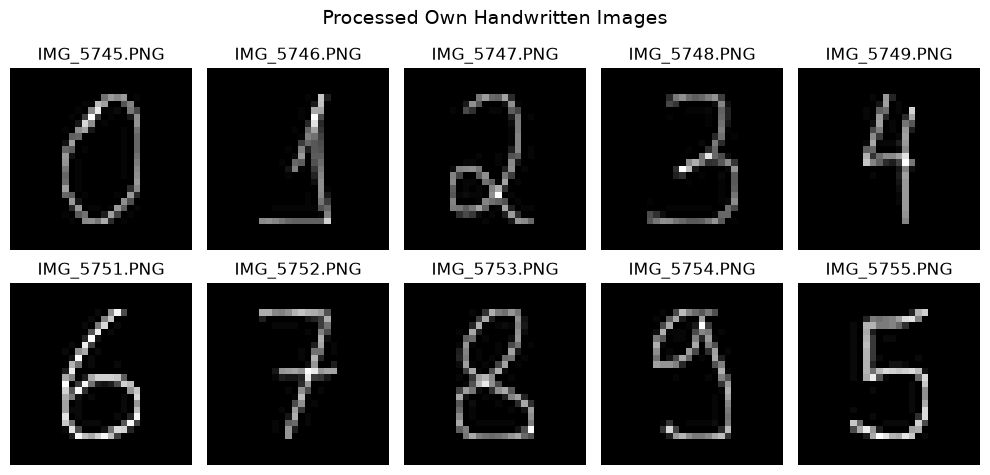

In [151]:
# Display the processed handwritten digits to verify the preprocessing.
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax, image, name in zip(
    axes.ravel(),
    X_own,
    own_image_names
):
    ax.imshow(image, cmap="gray")
    ax.set_title(name)
    ax.axis("off")

plt.suptitle("Processed Own Handwritten Images", fontsize=14)
plt.tight_layout()
plt.show()

In [152]:
# Flatten each 28 × 28 image into 784 features,
# matching the MNIST representation used during training.
X_own_flat = X_own.reshape(len(X_own), 784)

print("Model input shape:", X_own_flat.shape)

Model input shape: (10, 784)


In [153]:
# Predict the handwritten digits using the selected Scikit-learn MLP.
own_predictions = mlp_model.predict(X_own_flat)

# Obtain the probability distribution across all ten classes.
own_probabilities = mlp_model.predict_proba(X_own_flat)

print("Predictions:")
for name, prediction in zip(own_image_names, own_predictions):
    print(f"{name}: {prediction}")

Predictions:
IMG_5745.PNG: 5
IMG_5746.PNG: 5
IMG_5747.PNG: 2
IMG_5748.PNG: 5
IMG_5749.PNG: 4
IMG_5751.PNG: 5
IMG_5752.PNG: 2
IMG_5753.PNG: 5
IMG_5754.PNG: 5
IMG_5755.PNG: 5


/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [154]:
# Check that the probability outputs are valid.
print(
    f"Probability range: "
    f"{own_probabilities.min():.4f} to "
    f"{own_probabilities.max():.4f}"
)

print(
    f"Probability sum range: "
    f"{own_probabilities.sum(axis=1).min():.4f} to "
    f"{own_probabilities.sum(axis=1).max():.4f}"
)

print(
    "Contains NaN:",
    np.isnan(own_probabilities).any()
)

print(
    "Contains infinite values:",
    np.isinf(own_probabilities).any()
)

Probability range: 0.0040 to 0.6264
Probability sum range: 1.0000 to 1.0000
Contains NaN: False
Contains infinite values: False


In [155]:
# Define the true digit for each handwritten image.
# The order matches own_image_names and the processed images.

own_true_labels = np.array([
    0, 1, 2, 3, 4,
    6, 7, 8, 9, 5
])

# Calculate accuracy on the ten handwritten images.
own_accuracy = accuracy_score(
    own_true_labels,
    own_predictions
)

print(f"Own handwritten image accuracy: {own_accuracy:.4f}")
print(
    f"Correct predictions: "
    f"{np.sum(own_predictions == own_true_labels)}/{len(own_true_labels)}"
)

Own handwritten image accuracy: 0.3000
Correct predictions: 3/10


In [156]:
# Display the true and predicted labels for each handwritten image.

own_results = pd.DataFrame({
    "Image": own_image_names,
    "True digit": own_true_labels,
    "Predicted digit": own_predictions,
    "Correct": own_predictions == own_true_labels,
    "Confidence": own_probabilities.max(axis=1)
})

print(own_results.to_string(index=False))

       Image  True digit  Predicted digit  Correct  Confidence
IMG_5745.PNG           0                5    False    0.386304
IMG_5746.PNG           1                5    False    0.512947
IMG_5747.PNG           2                2     True    0.322184
IMG_5748.PNG           3                5    False    0.286244
IMG_5749.PNG           4                4     True    0.391223
IMG_5751.PNG           6                5    False    0.626362
IMG_5752.PNG           7                2    False    0.232239
IMG_5753.PNG           8                5    False    0.477554
IMG_5754.PNG           9                5    False    0.347996
IMG_5755.PNG           5                5     True    0.500514


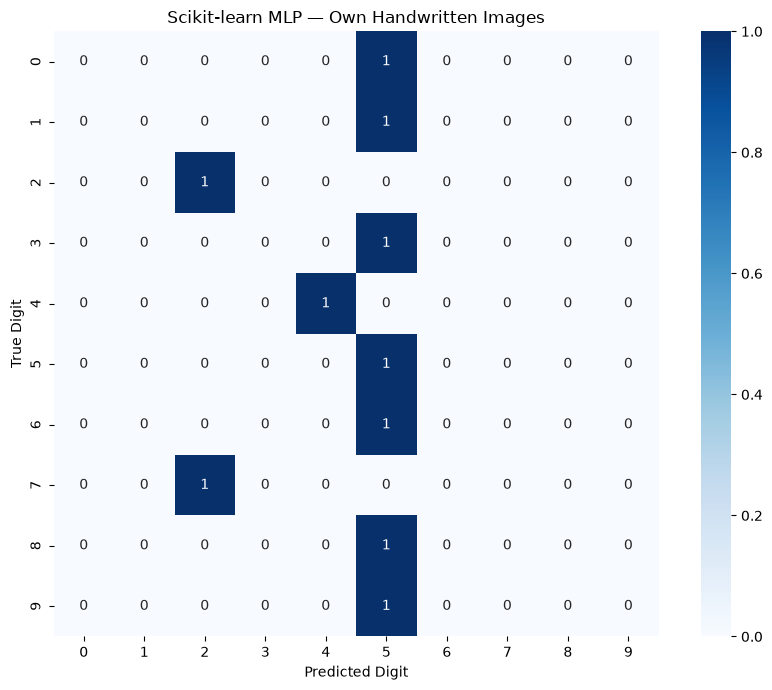

In [157]:
# Create a confusion matrix for the ten handwritten images.
own_confusion_matrix = confusion_matrix(
    own_true_labels,
    own_predictions,
    labels=range(10)
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    own_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    square=True,
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title("Scikit-learn MLP — Own Handwritten Images")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.tight_layout()
plt.show()

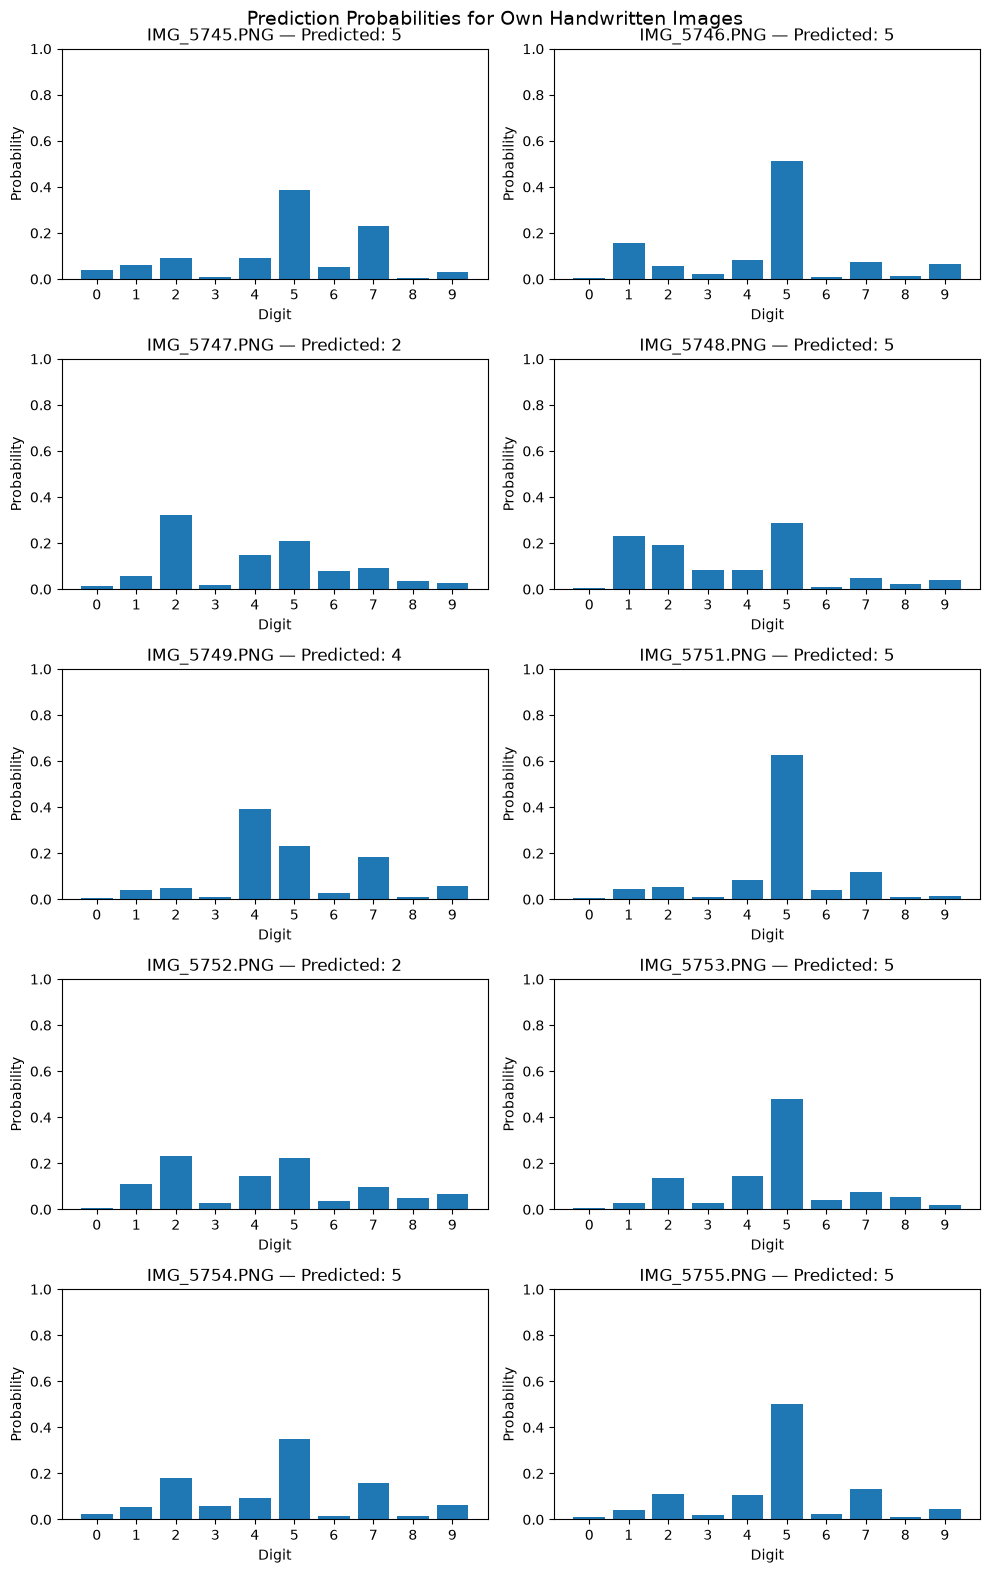

In [158]:
# Show the model's predicted probability distribution for each handwritten image.
# Each chart contains the probabilities for all ten MNIST classes.

fig, axes = plt.subplots(5, 2, figsize=(10, 16))

for ax, image_name, probabilities, prediction in zip(
    axes.ravel(),
    own_image_names,
    own_probabilities,
    own_predictions
):
    ax.bar(range(10), probabilities)
    ax.set_xticks(range(10))
    ax.set_xlabel("Digit")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1)
    ax.set_title(f"{image_name} — Predicted: {prediction}")

plt.suptitle(
    "Prediction Probabilities for Own Handwritten Images",
    fontsize=14
)
plt.tight_layout()
plt.show()

### 5.3 Interpretation

The Scikit-learn MLP correctly classified 3 of the 10 handwritten images, resulting in an accuracy of 30%.

The model correctly identified digits 2, 4, and 5. Most of the remaining images were classified as digit 5, with the handwritten digit 7 classified as 2.

The relatively low accuracy is expected because these images were created outside the MNIST dataset and may differ from MNIST in handwriting style, stroke thickness, positioning, scale, contrast, and image acquisition conditions.

The preprocessing attempted to reduce some of these differences by converting the images to grayscale, inverting the pixel values, cropping the digit, preserving its aspect ratio, resizing it, centering it on a 28 × 28 canvas, and normalizing the pixel values.

The prediction probabilities were valid and summed to 1 for every image. The model's maximum probabilities ranged from approximately 0.003 to 0.677, indicating generally moderate confidence rather than the very high confidence observed when the restricted model was tested on completely unseen classes in Challenge B.

Because only ten handwritten images were evaluated, the 30% accuracy should not be interpreted as a general performance estimate. Instead, this experiment demonstrates that a model with high MNIST test-set accuracy can still experience a substantial performance drop when applied to user-generated handwritten images with a different data distribution.

Overall, Phase 5 demonstrates two important robustness limitations: a closed-set classifier can confidently assign unseen classes to known categories, and performance can decrease considerably when the input data differs from the original training distribution.